# Analyze the results of the T cell parameter estimations

Generates Figures 5a and 5b.

It requires that the parameter estimation has been completed and there exists a file with those results. Edit the location of those files below.

## Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.formula import api as smf
import os
import seaborn as sns
from sklearn.metrics import mean_squared_error
from scipy.stats import ttest_ind
from estimator import Estimator
from src import pyxfunc
import time

## User-defined parameters

In [2]:
growth_data_file = "data/growth_data_df.csv"
config_file = "config_files/config_t.json"

result_path = "/data/hirschmg/tumor_dynamics/2026/final_results/c_a_f_b/"

figure_save_path = "figures/" # Set to None to not save figures
best_value_save_path = "bests/" # Set to None to not save

## Set up

In [3]:
# groups_nude = ["Grp. B1 nude (100% C1)", "Grp. B2 nude (80% C1; 20% C11)", "Grp. B3 nude (50% C1; 50% C11)", "Grp. B4 nude (20% C1; 80% C11)", "Grp. B5 nude (100% C11)"]
groups_b6 = ["Grp. A1 B6 (100% C1)", "Grp. A2 B6 (80% C1; 20% C11)", "Grp. A3 B6 (50% C1; 50% C11)", "Grp. A4 B6 (20% C1; 80% C11)", "Grp. A5 B6 (100% C11)"]
growth_df = pd.read_csv(growth_data_file)
es = Estimator(config_file)
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]
growth_df.loc[growth_df["group"]=="1C", "group"] = "Grp. A1 B6 (100% C1)"
growth_df.loc[growth_df["group"]=="2C", "group"] = "Grp. A2 B6 (80% C1; 20% C11)"
growth_df.loc[growth_df["group"]=="3C", "group"] = "Grp. A3 B6 (50% C1; 50% C11)"
growth_df.loc[growth_df["group"]=="4C", "group"] = "Grp. A4 B6 (20% C1; 80% C11)"
growth_df.loc[growth_df["group"]=="5C", "group"] = "Grp. A5 B6 (100% C11)"

## Read in and prep data

In [4]:
df = []
for fname in [f for f in os.listdir(result_path)]:
    temp = pd.read_csv(result_path+fname)
    temp = temp[~(temp["id"].isin(exclude))]
    df += [temp]
df = pd.concat(df)
df = df.drop_duplicates()
df = df[df["error"] != np.inf]
df["log_error"] = np.log(df["error"])
df

,group,id,g1,g11,m,k,c,a,f,b,l,error,winner,d,log_error
0,Grp. A1 B6 (100% C1),424,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.01,0.01,1.348847e+08,0,NaN,18.719931
1,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.01,0.01,5.381148e+12,0,NaN,29.313923
2,Grp. A1 B6 (100% C1),427,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.01,0.01,4.322136e+10,0,NaN,24.489601
3,Grp. A1 B6 (100% C1),424,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.02,0.01,1.355618e+08,0,NaN,18.724938
4,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.02,0.01,5.413486e+12,0,NaN,29.319914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499632,2C,648,0.166,0.141,-0.080,0.07,NaN,0.8,1.6,0.07,0.01,4.309224e+06,0,0.18,15.276268
499633,2C,627,0.166,0.141,-0.080,0.07,NaN,0.8,1.6,0.08,0.01,8.941860e+06,0,0.18,16.006254
499634,2C,633,0.166,0.141,-0.080,0.07,NaN,0.8,1.6,0.08,0.01,3.329785e+08,0,0.18,19.623589
499635,2C,637,0.166,0.141,-0.080,0.07,NaN,0.8,1.6,0.08,0.01,2.048964e+07,0,0.18,16.835430


In [5]:
df.loc[df["group"]=="1C", "group"] = "Grp. A1 B6 (100% C1)"
df.loc[df["group"]=="2C", "group"] = "Grp. A2 B6 (80% C1; 20% C11)"
df.loc[df["group"]=="3C", "group"] = "Grp. A3 B6 (50% C1; 50% C11)"
df.loc[df["group"]=="4C", "group"] = "Grp. A4 B6 (20% C1; 80% C11)"
df.loc[df["group"]=="5C", "group"] = "Grp. A5 B6 (100% C11)"
df

,group,id,g1,g11,m,k,c,a,f,b,l,error,winner,d,log_error
0,Grp. A1 B6 (100% C1),424,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.01,0.01,1.348847e+08,0,NaN,18.719931
1,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.01,0.01,5.381148e+12,0,NaN,29.313923
2,Grp. A1 B6 (100% C1),427,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.01,0.01,4.322136e+10,0,NaN,24.489601
3,Grp. A1 B6 (100% C1),424,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.02,0.01,1.355618e+08,0,NaN,18.724938
4,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.025,-0.01,0.02,0.1,0.1,0.02,0.01,5.413486e+12,0,NaN,29.319914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499632,Grp. A2 B6 (80% C1; 20% C11),648,0.166,0.141,-0.080,0.07,NaN,0.8,1.6,0.07,0.01,4.309224e+06,0,0.18,15.276268
499633,Grp. A2 B6 (80% C1; 20% C11),627,0.166,0.141,-0.080,0.07,NaN,0.8,1.6,0.08,0.01,8.941860e+06,0,0.18,16.006254
499634,Grp. A2 B6 (80% C1; 20% C11),633,0.166,0.141,-0.080,0.07,NaN,0.8,1.6,0.08,0.01,3.329785e+08,0,0.18,19.623589
499635,Grp. A2 B6 (80% C1; 20% C11),637,0.166,0.141,-0.080,0.07,NaN,0.8,1.6,0.08,0.01,2.048964e+07,0,0.18,16.835430


In [6]:
df.loc[df["group"]=="Grp. A1 B6 (100% C1)", "g11"] = 0
df.loc[df["group"]=="Grp. A1 B6 (100% C1)","m"] = 0
df.loc[df["group"]=="Grp. A1 B6 (100% C1)","k"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","c"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","a"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","f"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","b"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","m"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","k"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","g1"] = 0
df = df.drop_duplicates()
df = df.reset_index()

## Find top $n$ tuples with the lowest error

In [ ]:
n = 100
bests = []
for mid in df[df["group"] != "Grp. A5 B6 (100% C11)"]["id"].unique():
    m_df = df[df["id"] == mid]
    m_df = m_df.sort_values("error").reset_index()
    cutoff = m_df.loc[(n-1),"error"]
    m_df = m_df[m_df["error"] <= cutoff]
    bests += [m_df]
bests = pd.concat(bests)
bests = bests[bests["id"]!=602]
bests = bests.drop(["index", "level_0"], axis=1)
bests = bests.drop_duplicates()
bests = bests.sort_values(["group", "id"])
bests

In [10]:
if best_value_save_path:
    bests.to_csv(best_value_save_path+"t_{}.csv".format(n))

In [14]:
bests.loc[bests["group"]=="Grp. A1 B6 (100% C1)", "group"] = "A1"
bests.loc[bests["group"]=="Grp. A2 B6 (80% C1; 20% C11)", "group"] = "A2"
bests.loc[bests["group"]=="Grp. A3 B6 (50% C1; 50% C11)", "group"] = "A3"
bests.loc[bests["group"]=="Grp. A4 B6 (20% C1; 80% C11)", "group"] = "A4"

# Plot best results

In [42]:
def plot_best(bests):
    # bests = []
    ylim = (growth_df[growth_df["group"].isin(groups_b6)]["size"].max())+50
    xlim = growth_df[growth_df["group"].isin(groups_b6)]["day"].max()+2
        
    # Change figure size at the last part of this line if needed. First value is width, second value is height.
    fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12,8))
    for i in range(0,5):
        axes[0][i].set_ylim([-1, ylim])
        axes[0][i].set_xlim([6, xlim])
        # Plot true data
        group_df = growth_df[growth_df["group"] == groups_b6[i]]
        
        for mid in group_df["id"].unique():
            # Plot true data
            axes[0][i].plot(group_df[group_df["id"]==mid]["day"], (np.abs(group_df[group_df["id"]==mid]["size"])), color="black", linewidth=1)
            
            # Plot estimated data
            init = es.get_init(groups_b6[i], mid)
            end_time = group_df[group_df["id"]==mid]["day"].max()
            
            best = bests[bests["id"]==mid].sort_values("error")
                        
            sol = pyxfunc.run(init[0], init[1], init[2], 7.0, end_time, es.delay, es.cutoff_0_raw, es.cutoff_0_percent, init[2], best["g1"].tolist()[0], best["g11"].tolist()[0],
                                best["m"].tolist()[0], best["k"].tolist()[0], best["c"].tolist()[0], best["a"].tolist()[0], best["f"].tolist()[0], best["b"].tolist()[0], best["l"].tolist()[0])
            sol[0] = np.asarray(sol[0])
            sol[1] = np.asarray(sol[1])
            sol[2] = np.asarray(sol[2])
            sol[3] = np.asarray(sol[3])
            total_size = sol[0]+sol[1]

            # plot the winning subline second so it shows up
            if sol[0][-1] > sol[1][-1]: 
                axes[0][i].plot(sol[3], ((sol[1])), color="blue", label="C11", alpha=0.6)
                axes[0][i].plot(sol[3], ((sol[0])), color="orange", label="C1", alpha=0.8)
                color = "orange"
            else:
                axes[0][i].plot(sol[3], ((sol[0])), color="orange", label="C1", alpha=0.8)
                axes[0][i].plot(sol[3], ((sol[1])), color="blue", label="C11", alpha=0.6)
                color = "blue"
    
            # plot the ratios
            axes[1][i].plot(total_size, sol[0]/total_size, color="orange", label="C1")
            axes[1][i].plot(total_size, sol[1]/total_size, color="blue", label="C11")

            # plot the T cells
            axes[2][i].plot(total_size, sol[2]/(total_size+sol[2]), color="magenta", label="T")
            axes[2][i].set_ylim([0, 0.04])
            
            axes[0][i].set_title(groups_b6[i][5:7])
    axes[0][0].set_ylabel("Subclone (mm^3)")
    axes[1][0].set_ylabel("Subclone / (C1 + C11)")
    axes[2][0].set_ylabel("T cell / (C1 + C11 + T cell)")
    plt.tight_layout()
    if figure_save_path:
        plt.savefig(figure_save_path+"b6_predictions.svg")
    plt.show()

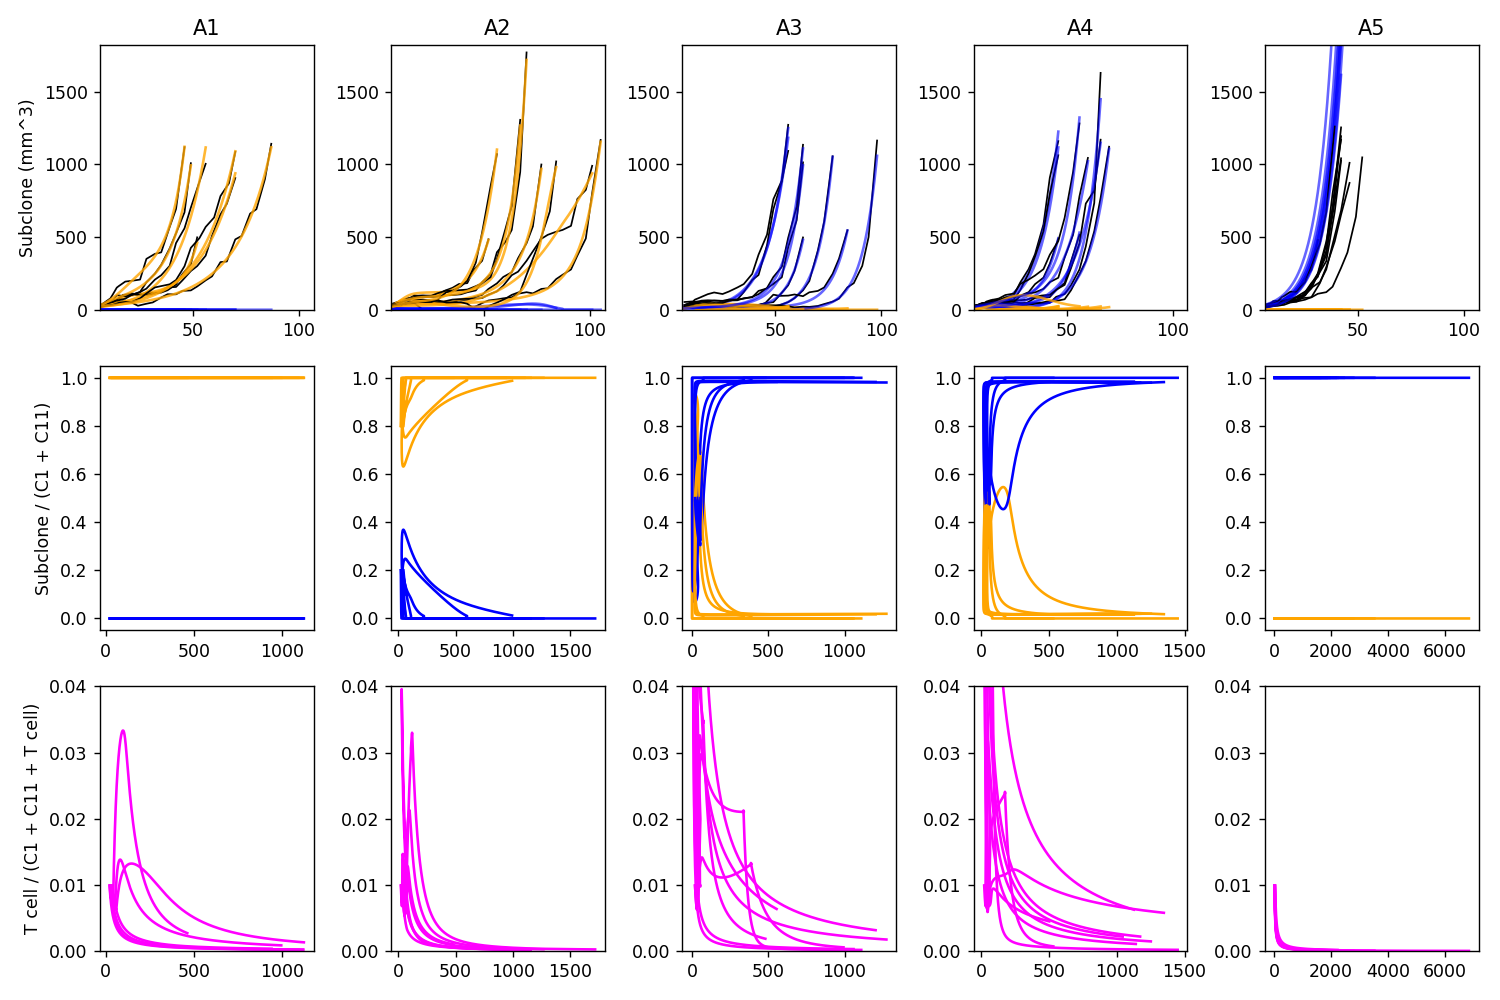

In [44]:
plot_best(bests)

## Plot distributions of parameters across groups

In [15]:
bests["logaf"] = np.log(bests["a"]/bests["f"])
bests["logbc"] = np.log(bests["b"]/bests["c"])
bests["logkm"] = np.log(bests["k"]/np.abs(bests["m"]))
bests_no_a5 = bests[bests["group"]!="Grp. A5 B6 (100% C11)"]
bests_no_a5 = bests_no_a5[bests_no_a5["id"]!=602]
bests_no_a5 = bests_no_a5.reset_index()

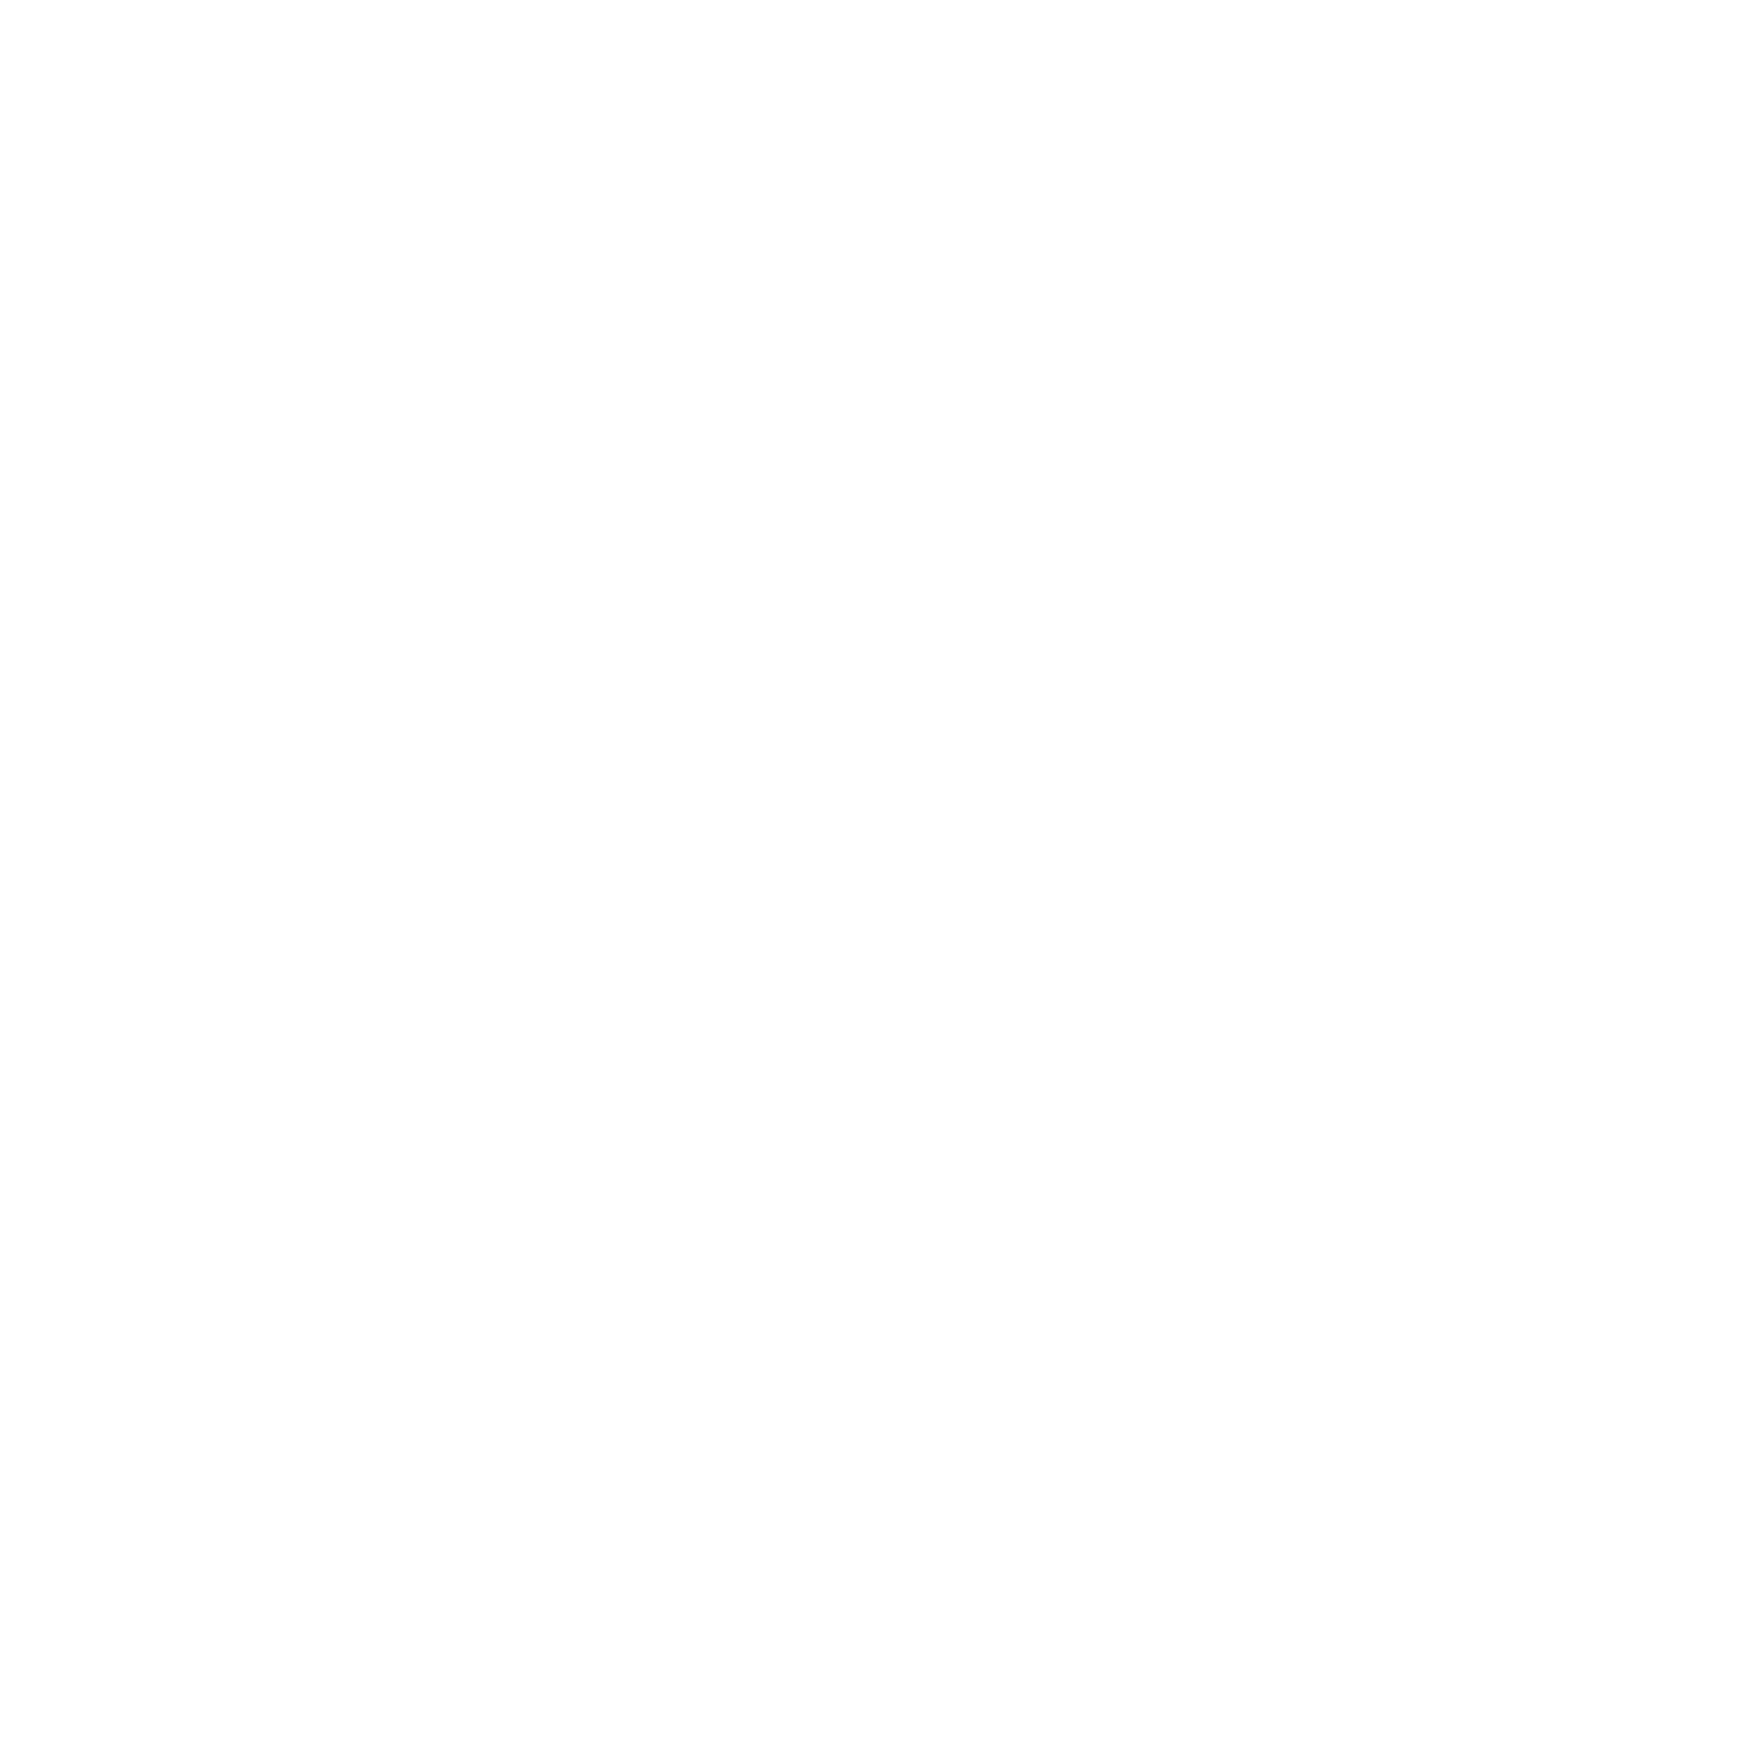

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14,14))
sns.boxplot(bests_no_a5[bests_no_a5["group"]!="A1"], x="group", y="k", hue="group", fliersize=1, ax=axes[0][0])
axes[0][0].set_title("k")
sns.boxplot(bests_no_a5[bests_no_a5["group"]!="A1"], x="group", y="m", hue="group", fliersize=1, ax=axes[0][1])
axes[0][1].set_title("m")
sns.boxplot(bests_no_a5[bests_no_a5["group"]!="A1"], x="group", y="logkm", hue="group", fliersize=1, ax=axes[0][2])
axes[0][2].set_title("log(k/m)")
sns.boxplot(bests_no_a5, x="group", y="c", hue="group", fliersize=1, ax=axes[1][0])
axes[1][0].set_title("c")
sns.boxplot(bests_no_a5, x="group", y="b", hue="group", fliersize=1, ax=axes[1][1])
axes[1][1].set_title("b")
sns.boxplot(bests_no_a5, x="group", y="logbc", hue="group", fliersize=1, ax=axes[1][2])
axes[1][2].set_title("log(b/c)")
sns.boxplot(bests_no_a5, x="group", y="a", hue="group", fliersize=1, ax=axes[2][0])
axes[2][0].set_title("a")
sns.boxplot(bests_no_a5, x="group", y="f", hue="group", fliersize=1, ax=axes[2][1])
axes[2][1].set_title("f")
sns.boxplot(bests_no_a5, x="group", y="logaf", hue="group", fliersize=1, ax=axes[2][2])
axes[2][2].set_title("log(a/f)")
plt.suptitle("Top {} best for T cell params".format(n))
plt.tight_layout()
if figure_save_path:
    plt.savefig(figure_save_path+"b6_boxplots.svg")
plt.show()

In [53]:
plt.close("all")

## P values between groups for each parameter

In [19]:
short_groups = ["A1", "A2", "A3", "A4"]
pvalues = []
for param in ["c", "a", "f", "b", "logbc", "logaf", "logafb"]:
    for i in range(0, 4):
        for j in range(i+1, 4):
            if i == j: continue
            ttest = ttest_ind(bests_no_a5[bests_no_a5["group"]==short_groups[i]][param], bests_no_a5[bests_no_a5["group"]==short_groups[j]][param])
            pvalues += [[param, short_groups[i], short_groups[j], ttest.pvalue]]
pvalues = pd.DataFrame(pvalues, columns=["param", "group1", "group2", "pvalue"])
pvalues

,param,group1,group2,pvalue
0,c,A1,A2,NaN
1,c,A1,A3,NaN
2,c,A1,A4,NaN
3,c,A2,A3,NaN
4,c,A2,A4,NaN
5,c,A3,A4,5.293540e-19
6,a,A1,A2,2.038519e-109
7,a,A1,A3,7.821540e-40
8,a,A1,A4,4.474905e-55
9,a,A2,A3,1.218937e-19


## Linear relationships between the parameters

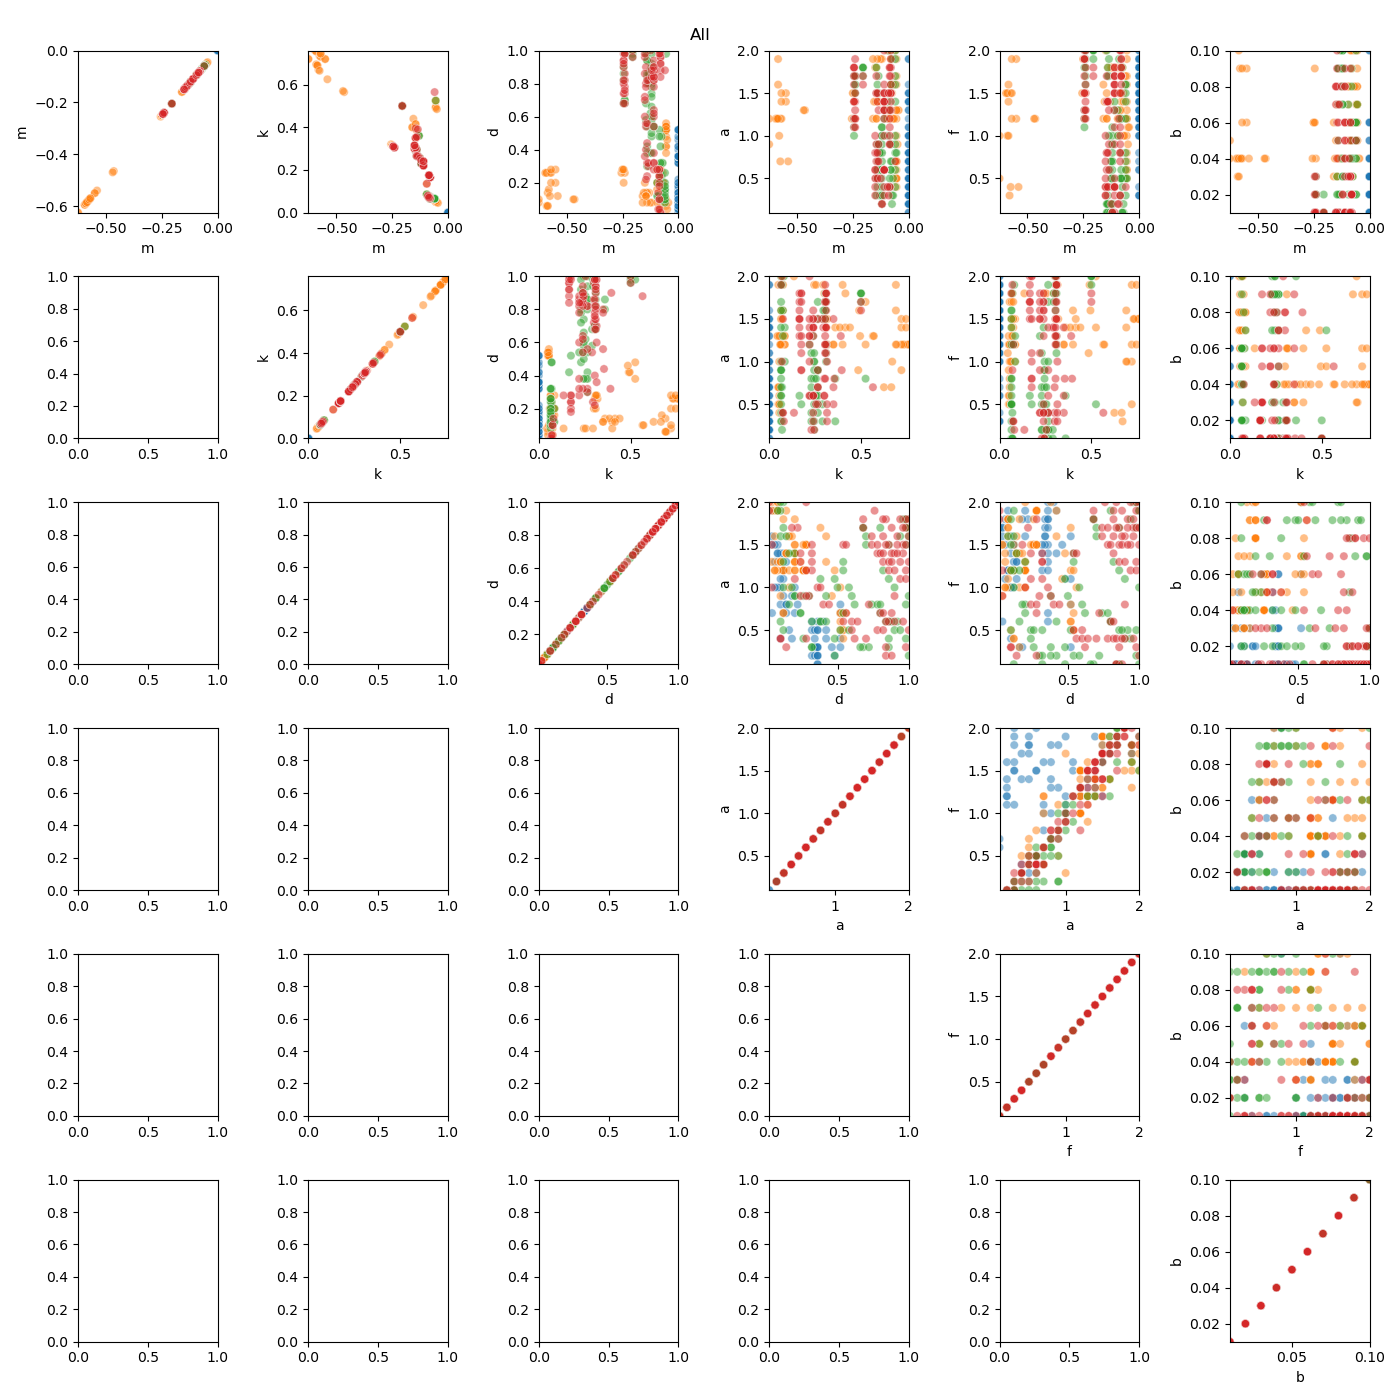

In [15]:
params = ["m", "k", "c", "a", "f", "b"]
group = 3
fig, axes = plt.subplots(nrows=len(params), ncols=len(params), figsize=(14,14))
for i in range(len(params)):
    for j in range(i, len(params)):
        sns.scatterplot(bests_no_a5, x=params[i], y=params[j], hue="group", alpha=0.5, legend=False, ax=axes[i][j])
        axes[i][j].set(xlabel= params[i], ylabel=params[j], xlim=(bests_no_a5[params[i]].min(), bests_no_a5[params[i]].max()), ylim=(bests_no_a5[params[j]].min(), bests_no_a5[params[j]].max()))
fig.suptitle("All")
plt.tight_layout()
plt.show()

In [ ]:
# R^2 values for a linear relationship between c and a
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("c~a", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

In [ ]:
# R^2 values for a linear relationship between c and f
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("c~f", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

In [ ]:
# R^2 values for a linear relationship between c and b
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("c~b", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

In [ ]:
# R^2 values for a linear relationship between a and f
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("a~f", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

In [ ]:
# R^2 values for a linear relationship between a and b
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("a~b", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

In [ ]:
# R^2 values for a linear relationship between f and b
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("f~b", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))